# Assignment4 - Neural Networks

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


## Exercise 1 - Exploring and optimizing neural network hyperparameters

In [1]:
# Optional for clear plotting on Macs
# %config InlineBackend.figure_format='retina'

# Some of the network training leads to warnings. When we know and are OK with 
#  what's causing the warning and simply don't want to see it, we can use the 
#  following code. Run this block
#  to disable warnings
import sys
import os
import warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = 'ignore'

In [2]:
import numpy as np
from sklearn.model_selection import PredefinedSplit

#-----------------------------------------------------------------------------
# Create the data
#-----------------------------------------------------------------------------
# Data generation function to create a checkerboard-patterned dataset
def make_data_normal_checkerboard(n, noise=0):
    n_samples = int(n/4)
    shift = 0.5
    c1a = np.random.randn(n_samples,2)*noise + [-shift, shift]
    c1b = np.random.randn(n_samples,2)*noise + [shift, -shift]
    c0a = np.random.randn(n_samples,2)*noise + [shift, shift]
    c0b = np.random.randn(n_samples,2)*noise + [-shift, -shift]
    X = np.concatenate((c1a,c1b,c0a,c0b),axis=0)
    y = np.concatenate((np.ones(2*n_samples), np.zeros(2*n_samples)))
    
    # Set a cutoff to the data and fill in with random uniform data:
    cutoff = 1.25
    indices_to_replace = np.abs(X)>cutoff
    for index,value in enumerate(indices_to_replace.ravel()):
        if value:
            X.flat[index] = np.random.rand()*2.5-1.25
    return (X,y)

# Training datasets
np.random.seed(42)
noise = 0.45
X_train,y_train = make_data_normal_checkerboard(500, noise=noise)
    
# Validation and test data
X_val,y_val = make_data_normal_checkerboard(500, noise=noise)
X_test,y_test = make_data_normal_checkerboard(500, noise=noise)

# For RandomSeachCV, we will need to combine training and validation sets then
#  specify which portion is training and which is validation
# Also, for the final performance evaluation, train on all of the training AND 
#  validation data
X_train_plus_val = np.concatenate((X_train, X_val), axis=0)
y_train_plus_val = np.concatenate((y_train, y_val), axis=0)

# Create a predefined train/test split for RandomSearchCV (to be used later)
validation_fold = np.concatenate((-1*np.ones(len(y_train)), np.zeros(len(y_val))))
train_val_split = PredefinedSplit(validation_fold)

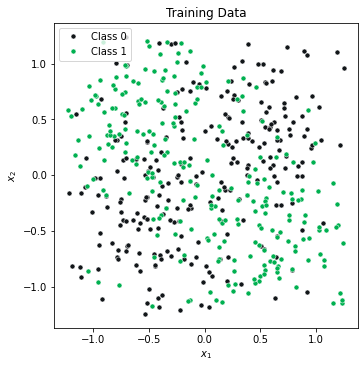

In [3]:
import matplotlib.pyplot as plt

# Code to plot the sample data
def plot_data(ax,X,y,title, limits):
    # Select the colors to use in the plots
    color0 = '#121619' # Dark grey
    color1 = '#00B050' # Green
    color_boundary='#858585'
    
    # Separate samples by class
    samples0 = X[y==0]
    samples1 = X[y==1]

    ax.plot(samples0[:,0],samples0[:,1],
        marker='o',
        markersize=5,
        linestyle="None",
        color=color0,
        markeredgecolor='w',
        markeredgewidth=0.5,
        label='Class 0')
    ax.plot(samples1[:,0],samples1[:,1],
        marker='o',
        markersize=5,
        linestyle="None",
        color=color1,
        markeredgecolor='w',
        markeredgewidth=0.5,
        label='Class 1')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(loc='upper left')
    ax.set_aspect('equal')

fig, ax = plt.subplots(constrained_layout=True, figsize=(5,5))
limits = [-1.25, 1.25, -1.25, 1.25]
plot_data(ax, X_train, y_train, 'Training Data', limits)

**1.1 Visualize teh impact of different hyperparameter choices**

In [4]:
from sklearn.neural_network import MLPClassifier

archs = [(2, 2), (5, 5), (30, 30)]
lrs = [0.0001, 0.01, 1]
regs = [0, 1, 10]
batches = [5, 50, 500]

def plot_decision_boundary(ax, clf, X, y, title):
    x_min, x_max = -1.25, 1.25
    y_min, y_max = -1.25, 1.25
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, colors=['#121619', '#00B050'])
    plot_data(ax, X, y, title, [x_min, x_max, y_min, y_max])

In [5]:
hyperparams = {
    'Architecture': ('hidden_layer_sizes', [(2, 2), (5, 5), (30, 30)]),
    'Learning Rate': ('learning_rate_init', [0.0001, 0.01, 1]),
    'Regularization': ('alpha', [0, 1, 10]),
    'Batch Size': ('batch_size', [5, 50, 500])
}

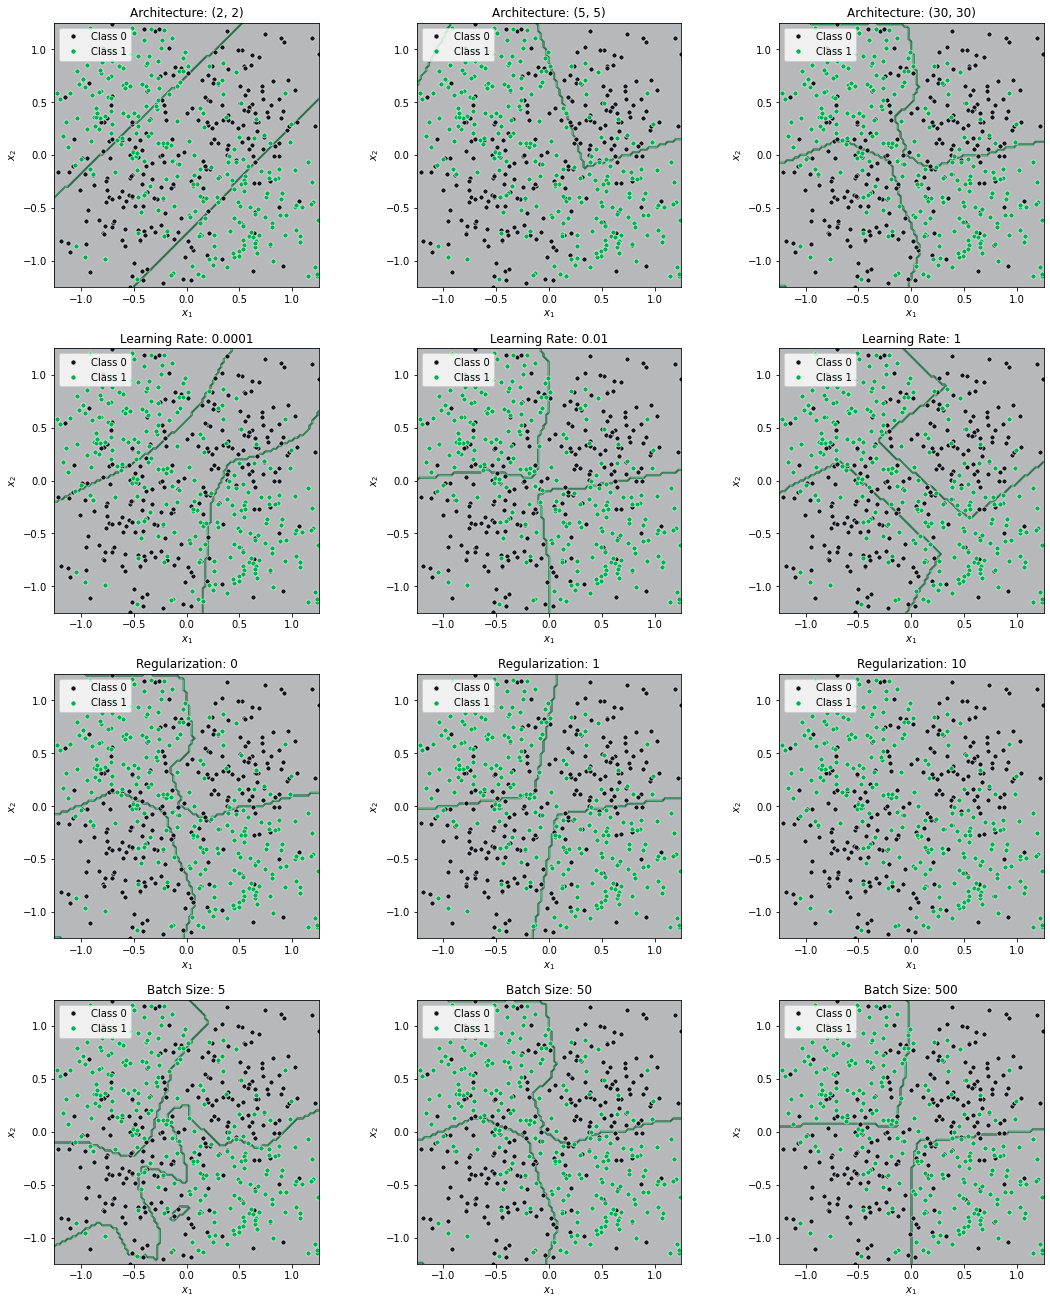

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18), constrained_layout=True)

# 遍歷每一列 (超參數種類)
for row_idx, (label, (param_name, values)) in enumerate(hyperparams.items()):
    for col_idx, val in enumerate(values):
        ax = axes[row_idx, col_idx]
        
        mlp_params = {
            'hidden_layer_sizes': (30, 30),
            'learning_rate_init': 0.03,
            'alpha': 0,
            'batch_size': 50,
            'solver': 'sgd',
            'tol': 1e-5,
            'early_stopping': False,
            'activation': 'relu',
            'n_iter_no_change': 1000,
            'max_iter': 500,
            'random_state': 42 
        }
        mlp_params[param_name] = val
        
        mlp = MLPClassifier(**mlp_params)
        mlp.fit(X_train, y_train)
        
        title = f"{label}: {val}"
        plot_decision_boundary(ax, mlp, X_train, y_train, title)

plt.show()

**1.2 Manual hyperparameter tuning**

To address the neural network's sensitivity to initial weight values, I did not rely on a single training run. Instead, I implemented a robust evaluation process by using three distinct random seeds [1, 50, 500] to simulate different starting conditions for the network. And calculating the mean validation accuracy across these three runs for every hyperparameter value

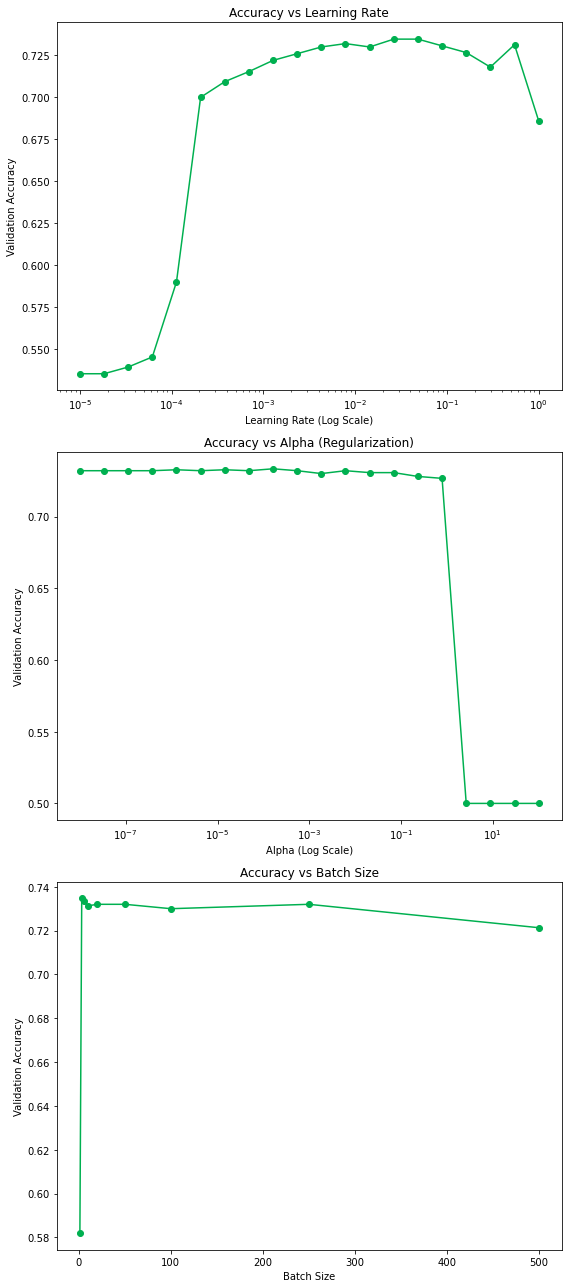

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

learning_rates = np.logspace(-5, 0, 20)  # 10^-5 to 10^0
alphas = np.logspace(-8, 2, 20)          # 10^-8 to 10^2
batch_sizes = [1, 3, 5, 10, 20, 50, 100, 250, 500]

base_params = {
    'hidden_layer_sizes': (30, 30),
    'learning_rate_init': 0.03,
    'alpha': 0,
    'batch_size': 50,
    'solver': 'sgd',
    'max_iter': 500,
    'random_state': None 
}

def get_scores(param_name, values):
    train_scores = []
    val_scores = []
    for val in values:
        params = base_params.copy()
        params[param_name] = val
        
        seeds = [1, 50, 500]
        tmp_val_acc = []
        for s in seeds:
            params['random_state'] = s
            mlp = MLPClassifier(**params).fit(X_train, y_train)
            tmp_val_acc.append(mlp.score(X_val, y_val))
            
        val_scores.append(np.mean(tmp_val_acc))
    return val_scores

fig, axes = plt.subplots(3, 1, figsize=(8, 18), constrained_layout=True)
# Plot 1: Learning Rate
val_lr = get_scores('learning_rate_init', learning_rates)
axes[0].semilogx(learning_rates, val_lr, 'o-', color='#00B050')
axes[0].set_title('Accuracy vs Learning Rate')
axes[0].set_xlabel('Learning Rate (Log Scale)')
axes[0].set_ylabel('Validation Accuracy')

# Plot 2: Regularization (Alpha)
val_alpha = get_scores('alpha', alphas)
axes[1].semilogx(alphas, val_alpha, 'o-', color='#00B050')
axes[1].set_title('Accuracy vs Alpha (Regularization)')
axes[1].set_xlabel('Alpha (Log Scale)')
axes[1].set_ylabel('Validation Accuracy')

# Plot 3: Batch Size
val_batch = get_scores('batch_size', batch_sizes)
axes[2].plot(batch_sizes, val_batch, 'o-', color='#00B050')
axes[2].set_title('Accuracy vs Batch Size')
axes[2].set_xlabel('Batch Size')
axes[2].set_ylabel('Validation Accuracy')

plt.tight_layout()
plt.show()

In [17]:
# 1. Finding the Best Learning Rate
best_lr_idx = np.argmax(val_lr) # Find index of highest accuracy
best_lr = learning_rates[best_lr_idx]
best_lr_score = val_lr[best_lr_idx]

# 2. Finding the Best Alpha
best_alpha_idx = np.argmax(val_alpha)
best_alpha = alphas[best_alpha_idx]
best_alpha_score = val_alpha[best_alpha_idx]

# 3. Finding the Best Batch Size
best_batch_idx = np.argmax(val_batch)
best_batch = batch_sizes[best_batch_idx]
best_batch_score = val_batch[best_batch_idx]

print("--- Optimal Hyperparameters Found ---")
print(f"Best Learning Rate: {best_lr:.6f} (Accuracy: {best_lr_score:.4f})")
print(f"Best Alpha:         {best_alpha:.6f} (Accuracy: {best_alpha_score:.4f})")
print(f"Best Batch Size:    {best_batch} (Accuracy: {best_batch_score:.4f})")

--- Optimal Hyperparameters Found ---
Best Learning Rate: 0.026367 (Accuracy: 0.7347)
Best Alpha:         0.000162 (Accuracy: 0.7333)
Best Batch Size:    3 (Accuracy: 0.7347)


**Optimal Hyperparameter Selection**        

Based on the validation performance plots and the exact data points extracted from the MLPClassifier.score method, I have selected the following optimal hyperparameters:
- Learning rate: The accuracy vs. learning rate plot shows a significant increase after $10^{-4}$ and reaches its peak at approximately 0.026367 .
- Alpha: I selected an alpha of $0.000162$ because it yielded the highest validation accuracy before the sharp performance drop-off observed when $alpha > 1$.
- Batch Size: Although the plot displays some noise due to initialization sensitivity, a batch size of $3$ achieved the highest overall accuracy ($0.7393$). I selected this because smaller batches introduce stochasticity that helps the model navigate the complex, non-linear boundaries of the checkerboard pattern more effectively than larger, more stable batches.        

Therefore, I choose learning rate(0.026367), alpha($0.000162$) and the batch size 3 to be my hyperparameter.

**1.3 Manual hyperparameter tuning II**

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

# Optimized parameters from 1.2
best_lr = 0.026367
best_alpha = 0.000162
best_batch = 3

nodes_per_layer = [1, 2, 3, 4, 5, 10, 15, 25, 30]
num_layers_list = [1, 2, 3, 4]
seeds = [1, 50, 500]

# Initialize results matrix
results_matrix = np.zeros((len(num_layers_list), len(nodes_per_layer)))

# Grid search for architecture
for i, layers in enumerate(num_layers_list):
    for j, nodes in enumerate(nodes_per_layer):
        # Create symmetric architecture (e.g., (15, 15) for 2 layers)
        current_arch = tuple([nodes] * layers)
        
        trial_scores = []
        for s in seeds:
            mlp = MLPClassifier(hidden_layer_sizes=current_arch, learning_rate_init=best_lr, alpha=best_alpha, batch_size=best_batch, solver='sgd', max_iter=500,
            random_state=s, early_stopping=False,n_iter_no_change=1000, tol=1e-5)
            mlp.fit(X_train, y_train)
            trial_scores.append(mlp.score(X_val, y_val))
        
        results_matrix[i, j] = np.mean(trial_scores)

# Heatmap Visualization
plt.figure(figsize=(12, 7))
ax = sns.heatmap(results_matrix, annot=True, fmt=".2f", xticklabels=nodes_per_layer, yticklabels=num_layers_list, cmap='YlGnBu')

plt.title('Validation Accuracy: Number of Layers vs Nodes per Layer')
plt.xlabel('Nodes per Layer')
plt.ylabel('Number of Layers')
plt.show()

# Find the absolute best for reference
max_idx = np.unravel_index(np.argmax(results_matrix, axis=None), results_matrix.shape)
print(f"Highest Accuracy: {results_matrix[max_idx]:.4f}")
print(f"Best Configuration: Layers={num_layers_list[max_idx[0]]}, Nodes={nodes_per_layer[max_idx[1]]}")